# Building your own JOLI operators #

From previous notebooks, we learned some basic JOLI operators, such as joDirac, joKron, and how to make a composite JOLI operator as well. In this script, we will show how to build your own JOLI operators based on function *joLinearFunctionFwd_T*.

```julia
    joLinearFunctionFwd_T(m::Integer,n::Integer,
        fop::Function,fop_T::Function,
        DDT::DataType,RDT::DataType=DDT;
        fMVok::Bool=false,
        name::String="joLinearFunctionFwd_T")
```

For example, suppose we are working on an image domain with size $(201,201)$ and grid spacing $(5,5)$. If we want to build a weighting operator, which gives lower weights in the center of the image, but higher weights if further from the center, e.g.

$$
\mathbf{W}(x,z) = \|(x-xc)_2^2+(y-zc)_2^2\|_2
$$

where $(xc,zc)$ is the coordinate of the center.

From the definition, this weighting operator is linear. Therefore, instead of building the matrix explicitly, we could build a JOLI operator which only requires the forward and adjoint actions. First, we can start with a forward function called *weighting*, which takes an input of the image, and gives an output of the weighted image.

In [1]:
using JOLI
using LinearAlgebra

In [2]:
function weighting(n, d, image)
    
    # n = (nx,nz), size of the image
    # d = (dx,dz), grid spacing
    # image, 2-D array
    
    xc = (n[1]-1)/2*d[1]
    zc = (n[1]-1)/2*d[1]
    x = zeros(n[1],1);
    x .= reshape((collect(1:n[1]).-1)*d[1], :, 1)
    z = zeros(1,n[2]);
    z .= reshape((collect(1:n[2]).-1)*d[2], 1, :)
    W = zeros(Float32,n[1],n[2])
    W .= sqrt.((x.-xc).^2f0.+(z.-zc).^2f0)
    
    return vec(W).*vec(image)
end

weighting (generic function with 1 method)

Since the weighting operator is self-adjoint (actually it is like a diagonal matrix), the adjoint is the same as the forward. Therefore, we can define the weighting operator as:

In [3]:
function weighting_operator(n,d)
    W_operator = joLinearFunctionFwd_T(prod(n), prod(n),
                                 v -> weighting(n,d,v),
                                 w -> weighting(n,d,w),
                                 Float32,Float32,name="Weighting operator")
    return W_operator
end

weighting_operator (generic function with 1 method)

Explanation on arguments of the *joLinearFunctionFwd_T* function: the first entry is the output size (number of rows of the matrix), the second entry is the input size (number of columns of the matrix), next 2 entries define the forward and the adjoint of this operator respectively (they are the same in this case), next 2 entries define the input and output data type, and finally we give a name for this operator. Also be careful that the input and output should be vectors.

Now let's see how the weighting operator works on the image!

In [4]:
n = (201,201)
d = (5,5)

(5, 5)

In [5]:
W = weighting_operator(n,d)

joLinearFunction{Float32,Float32}("Weighting operator", 40401, 40401, var"#1#3"{Tuple{Int64,Int64},Tuple{Int64,Int64}}((201, 201), (5, 5)), Nullable{Function}(var"#2#4"{Tuple{Int64,Int64},Tuple{Int64,Int64}}((201, 201), (5, 5))), Nullable{Function}(JOLI.var"#132#134"{var"#2#4"{Tuple{Int64,Int64},Tuple{Int64,Int64}}}(var"#2#4"{Tuple{Int64,Int64},Tuple{Int64,Int64}}((201, 201), (5, 5)))), Nullable{Function}(JOLI.var"#133#135"{var"#1#3"{Tuple{Int64,Int64},Tuple{Int64,Int64}}}(var"#1#3"{Tuple{Int64,Int64},Tuple{Int64,Int64}}((201, 201), (5, 5)))), false, Nullable{Function}(), Nullable{Function}(), Nullable{Function}(), Nullable{Function}(), false)

After we create the JOLI linear operator, don't forget to do linearity test and adjoint test.

In [6]:
using Test, Printf

In [7]:
x1 = randn(Float32,prod(n))
x2 = randn(Float32,prod(n))
@test isapprox(W*(x1+x2), W*x1+W*x2)

Test Passed

In [8]:
x3 = randn(Float32,prod(n))
x4 = randn(Float32,prod(n))
@test isapprox(dot(x4,W*x3), dot(x3,W'*x4))

Test Passed

In [9]:
x = ones(Float32,prod(n))

40401-element Array{Float32,1}:
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 ⋮
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0

In [10]:
using PyPlot

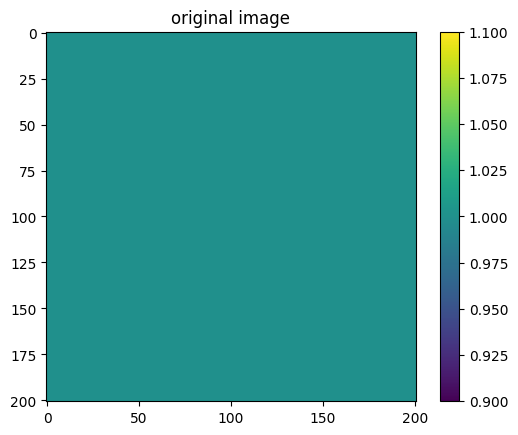

PyObject Text(0.5, 1.0, 'original image')

In [11]:
figure();imshow(reshape(x,n)');colorbar();title("original image")

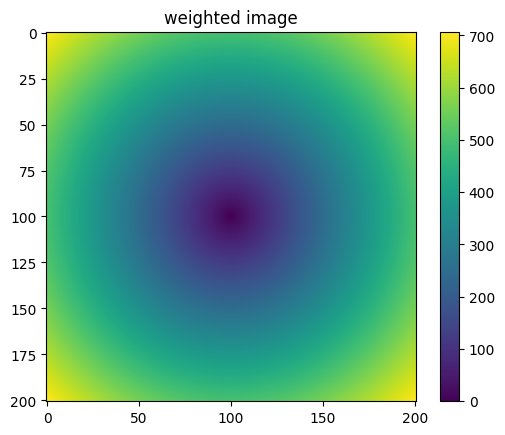

PyObject Text(0.5, 1.0, 'weighted image')

In [12]:
y = W*x
figure();imshow(reshape(y,n)');colorbar();title("weighted image")

The weighting operator works as expected. JOLI not only gives us the possibility to cast linear operators as "matrix" with size information and the ease of calculation, JOLI could also "fool" some iterative methods! We can actually put our JOLI linear operators into iterative solvers like LSQR or CG which only require the actions of forward and adjoint. Now, let's solve a "mini" inverse problem: if we know the weighted image, can we get the original image back?

$$ min_x \|y-\mathbf{W}x\|_2^2 $$

In [13]:
using IterativeSolvers

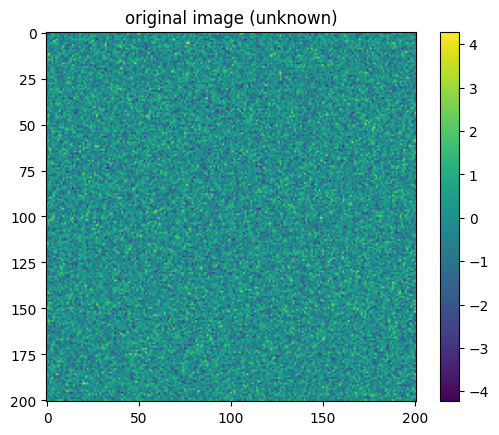

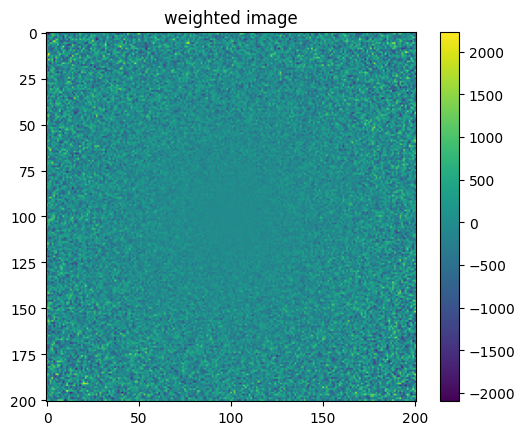

In [14]:
x = randn(Float32,prod(n))
y = W*x
figure();imshow(reshape(x,n)');title("original image (unknown)");colorbar();
figure();imshow(reshape(y,n)');title("weighted image");colorbar();

In [15]:
x_solve,ch = lsqr(W,y;maxiter=50,verbose=true,log=true)

=== lsqr ===
iter	resnorm		  anorm		  cnorm		  rnorm
  1	3.23e+04	7.97e-01	4.23e-02	3.91e-01
  2	1.74e+04	4.76e-01	2.06e-02	2.11e-01
  3	1.08e+04	3.59e-01	1.34e-02	1.31e-01
  4	7.40e+03	2.82e-01	9.80e-03	8.95e-02
  5	5.39e+03	2.35e-01	7.68e-03	6.52e-02
  6	4.09e+03	2.00e-01	6.27e-03	4.95e-02
  7	3.22e+03	1.76e-01	5.28e-03	3.89e-02
  8	2.59e+03	1.56e-01	4.54e-03	3.13e-02
  9	2.13e+03	1.40e-01	3.97e-03	2.58e-02
 10	1.79e+03	1.26e-01	3.52e-03	2.16e-02
 11	1.53e+03	1.15e-01	3.16e-03	1.85e-02
 12	1.32e+03	1.06e-01	2.85e-03	1.60e-02
 13	1.15e+03	9.92e-02	2.60e-03	1.39e-02
 14	1.01e+03	9.36e-02	2.38e-03	1.22e-02
 15	8.93e+02	8.86e-02	2.20e-03	1.08e-02
 16	7.93e+02	8.31e-02	2.04e-03	9.59e-03
 17	7.09e+02	7.89e-02	1.90e-03	8.58e-03
 18	6.38e+02	7.42e-02	1.77e-03	7.72e-03
 19	5.78e+02	7.02e-02	1.67e-03	6.99e-03
 20	5.25e+02	6.72e-02	1.57e-03	6.35e-03
 21	4.79e+02	6.39e-02	1.48e-03	5.80e-03
 22	4.40e+02	6.13e-02	1.40e-03	5.32e-03
 23	4.05e+02	5.84e-02	1.33e-03	4.90e-03
 24	3.74e+02	5.62e-02	1.26e

(Float32[-1.4057821, -0.8635699, 0.017318903, -0.9280104, -1.8991015, 0.0010213427, -0.9372976, 0.030335965, 0.13931869, 0.27731138  …  -0.30922407, -0.28542286, -0.14391117, -0.102318235, 1.2667391, 0.8483177, 0.17840417, 0.17597815, 0.42145023, -1.6918439], Converged after 32 iterations.)

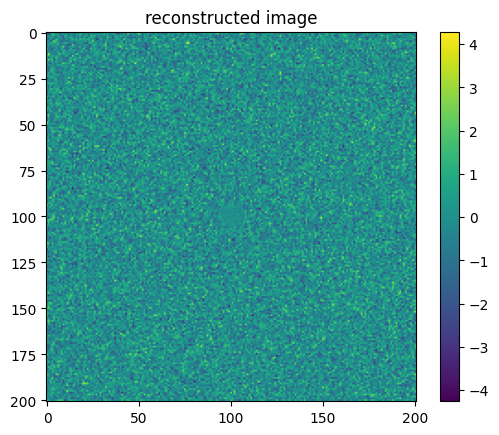

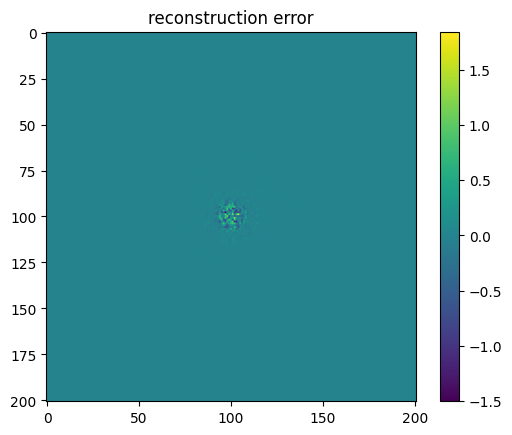

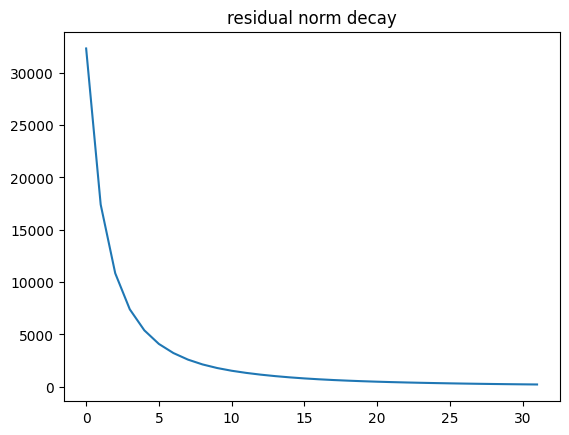

PyObject Text(0.5, 1.0, 'residual norm decay')

In [16]:
figure();imshow(reshape(x_solve,n)');title("reconstructed image");colorbar();
figure();imshow(reshape(x-x_solve,n)');title("reconstruction error");colorbar();
figure();plot(ch[:resnorm]);title("residual norm decay")

The center of the image is in null space of the operator so it does not get the perfect reconstruction. But we can clearly see JOLI linear operators are supported in iterative methods.

Finally, if you want to save your DIY JOLI operator, you could use the package JLD2.

In [17]:
using JLD2
@save "DIY_jo_op.jld2" W